# ARTI 403 — Image Processing Lab 1

## Camera and Lena edition for Google Colab

This self-contained notebook completes Lab 1 using:

- `skimage.data.camera()` for the OpenCV task.
- The course file `lena_gray_256.tif` for the PIL task and the later NumPy operations.

The Lena TIFF is embedded inside this notebook, so no separate image upload is required in Colab. Run every cell from top to bottom using **Runtime → Run all**.


## Learning outcomes

By completing this notebook, you will learn to:

1. Load images using OpenCV and PIL.
2. Display images using Matplotlib.
3. Save images to disk.
4. Represent images as NumPy arrays.
5. Inspect pixels, dimensions, shapes, and data types.
6. Perform basic image operations using NumPy.


## 1. Import the required libraries

Google Colab normally includes these packages. For a local computer, install them with:

```text
python -m pip install numpy matplotlib pillow scikit-image opencv-python
```


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import data

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Create folders

The notebook creates an `Images` folder for its source images and a `lab1_results` folder for processed images. These folders exist inside the current Colab session.


In [2]:
BASE_DIR = Path.cwd()
IMAGES_DIR = BASE_DIR / "Images"
RESULTS_DIR = BASE_DIR / "lab1_results"

IMAGES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Working folder:", BASE_DIR)
print("Images folder:", IMAGES_DIR)
print("Results folder:", RESULTS_DIR)


Working folder: /content
Images folder: /content/Images
Results folder: /content/lab1_results


## 3. Prepare the camera and Lena images

`data.camera()` supplies the grayscale camera sample. The exact `lena_gray_256.tif` course file is stored inside this notebook and restored into the `Images` folder when this cell runs.


In [3]:
import base64

camera_source = data.camera()
camera_path = IMAGES_DIR / "camera.png"
Image.fromarray(camera_source).save(camera_path)

lena_path = IMAGES_DIR / "lena_gray_256.tif"
LENA_TIFF_BASE64 = """..."""
lena_path.write_bytes(base64.b64decode(LENA_TIFF_BASE64))
lena_source = np.array(Image.open(lena_path))

print("Camera image saved:", camera_path)
print("Lena image restored:", lena_path)
print("Camera shape:", camera_source.shape)
print("Lena shape:", lena_source.shape)


Camera image saved: /content/Images/camera.png
Lena image restored: /content/Images/lena_gray_256.tif
Camera shape: (512, 512)
Lena shape: (256, 256)


## Task 1 — Display the two source images

Both images are grayscale, so each pixel contains one intensity value between 0 and 255.


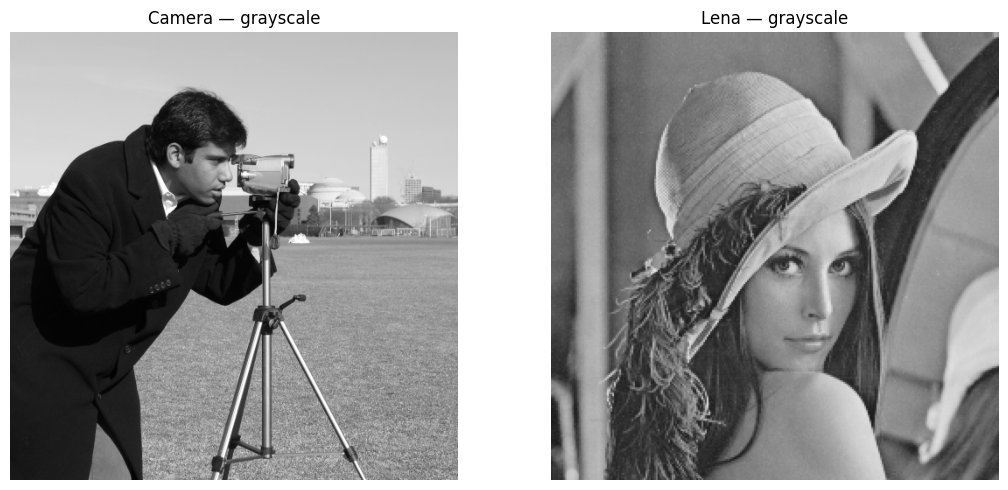

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(camera_source, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Camera — grayscale")
axes[0].axis("off")

axes[1].imshow(lena_source, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Lena — grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Task 2A — Load and visualize an image using OpenCV

`cv2.imread()` loads the camera file into a NumPy array. `cv2.IMREAD_GRAYSCALE` keeps it two-dimensional.


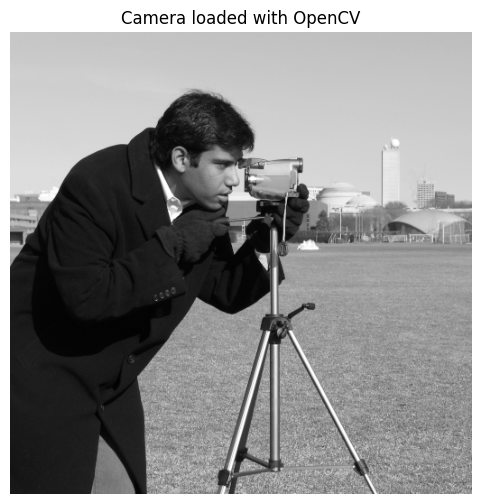

In [5]:
img_cv = cv2.imread(str(camera_path), cv2.IMREAD_GRAYSCALE)

if img_cv is None:
    raise FileNotFoundError(f"OpenCV could not load {camera_path}")

plt.figure(figsize=(6, 6))
plt.imshow(img_cv, cmap="gray", vmin=0, vmax=255)
plt.title("Camera loaded with OpenCV")
plt.axis("off")
plt.show()


## Task 2B — Load and visualize Lena using PIL

`Image.open()` loads `lena_gray_256.tif` as a PIL Image object. The grayscale colormap displays the pixel intensities correctly.


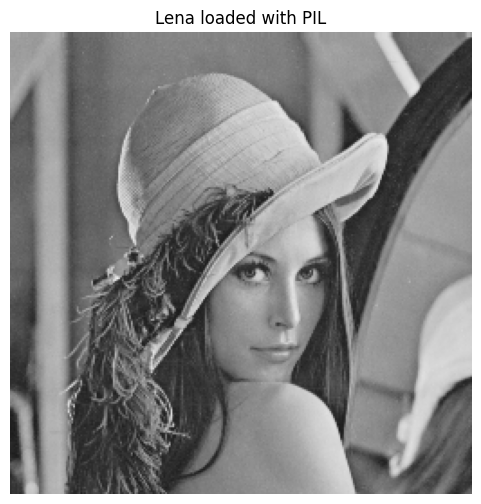

In [6]:
img_pil = Image.open(lena_path)

plt.figure(figsize=(6, 6))
plt.imshow(img_pil, cmap="gray", vmin=0, vmax=255)
plt.title("Lena loaded with PIL")
plt.axis("off")
plt.show()


## Task 3 — Save images to disk

OpenCV saves with `cv2.imwrite()`. PIL saves with the Image object's `.save()` method.


In [7]:
opencv_output = RESULTS_DIR / "camera_saved_with_opencv.jpg"
pil_output = RESULTS_DIR / "lena_saved_with_pil.jpg"

opencv_success = cv2.imwrite(str(opencv_output), img_cv)
img_pil.save(pil_output)

print("OpenCV save successful:", opencv_success)
print("OpenCV output:", opencv_output)
print("PIL output:", pil_output)


OpenCV save successful: True
OpenCV output: /content/lab1_results/camera_saved_with_opencv.jpg
PIL output: /content/lab1_results/lena_saved_with_pil.jpg


## Task 4A — Display the OpenCV image as an array

For this grayscale image, the shape is `(height, width)`. Pixel values range from `0` (black) to `255` (white).


In [8]:
print("Python type:", type(img_cv))
print("Shape:", img_cv.shape)
print("Number of dimensions:", img_cv.ndim)
print("Data type:", img_cv.dtype)
print()
print("First 10 rows and 10 columns:")
print(img_cv[:10, :10])


Python type: <class 'numpy.ndarray'>
Shape: (512, 512)
Number of dimensions: 2
Data type: uint8

First 10 rows and 10 columns:
[[200 200 200 200 199 200 199 198 199 198]
 [200 199 199 200 199 200 199 198 198 199]
 [199 199 199 200 200 200 200 200 200 200]
 [200 200 199 199 199 199 199 199 198 199]
 [200 200 200 200 199 199 199 200 199 199]
 [200 199 199 200 199 199 199 199 199 199]
 [200 201 200 200 199 200 198 199 199 199]
 [201 200 200 200 200 199 199 200 200 199]
 [200 200 200 199 200 200 200 199 199 199]
 [200 200 199 200 200 200 201 200 199 199]]


## Task 4B — Convert the PIL Lena image into a NumPy array

The grayscale Lena array has shape `(height, width)`. Every array element is one pixel intensity.


In [9]:
img_array = np.array(img_pil)

print("PIL object type:", type(img_pil))
print("Array type:", type(img_array))
print("Shape:", img_array.shape)
print("Number of dimensions:", img_array.ndim)
print("Data type:", img_array.dtype)
print("Pixel at row 100, column 100:", img_array[100, 100])
print()
print("First 10 rows and 10 columns:")
print(img_array[:10, :10])


PIL object type: <class 'PIL.TiffImagePlugin.TiffImageFile'>
Array type: <class 'numpy.ndarray'>
Shape: (256, 256)
Number of dimensions: 2
Data type: uint8
Pixel at row 100, column 100: 77

First 10 rows and 10 columns:
[[162 162 162 163 165 162 155 160 157 161]
 [162 162 162 163 165 162 155 160 157 161]
 [162 162 162 163 165 162 155 160 157 161]
 [160 163 160 159 159 156 155 156 153 154]
 [155 158 159 157 163 158 159 156 155 162]
 [156 156 156 155 158 157 159 158 155 153]
 [158 157 157 159 160 158 156 156 156 162]
 [158 159 155 158 155 151 157 156 155 155]
 [156 155 158 157 154 153 158 155 153 155]
 [157 159 158 154 157 154 157 161 159 159]]


## Assessment — NumPy image operations on Lena

From this point onward, the operations use the grayscale Lena array created in Task 4B.

### A. Calculate image statistics


In [10]:
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())
print("Mean pixel value:", round(float(img_array.mean()), 2))
print("Standard deviation:", round(float(img_array.std()), 2))
print("Pixel at row 100, column 100:", img_array[100, 100])


Minimum pixel value: 26
Maximum pixel value: 242
Mean pixel value: 124.01
Standard deviation: 47.84
Pixel at row 100, column 100: 77


### B. Crop the image using array slicing


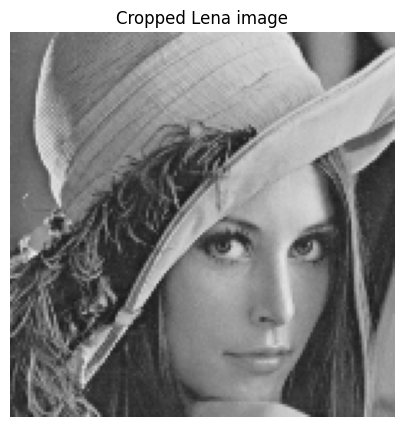

Original shape: (256, 256)
Cropped shape: (150, 150)


In [11]:
cropped = img_array[50:200, 50:200]

plt.figure(figsize=(5, 5))
plt.imshow(cropped, cmap="gray", vmin=0, vmax=255)
plt.title("Cropped Lena image")
plt.axis("off")
plt.show()

print("Original shape:", img_array.shape)
print("Cropped shape:", cropped.shape)


### C. Create a negative by subtracting every pixel from 255


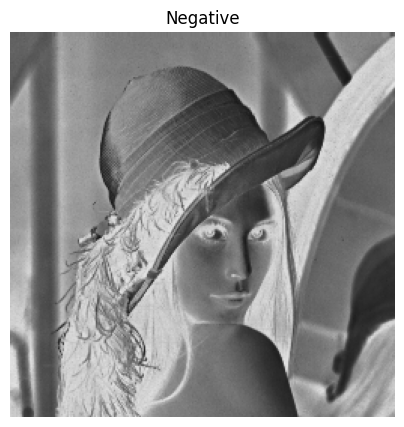

In [12]:
negative = 255 - img_array

plt.figure(figsize=(5, 5))
plt.imshow(negative, cmap="gray", vmin=0, vmax=255)
plt.title("Negative")
plt.axis("off")
plt.show()


### D. Increase brightness safely using addition and clipping


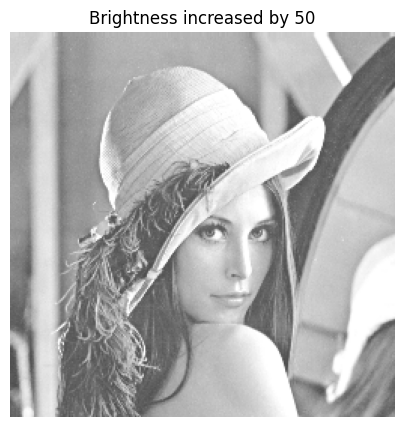

In [13]:
brighter = np.clip(img_array.astype(np.int16) + 50, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(brighter, cmap="gray", vmin=0, vmax=255)
plt.title("Brightness increased by 50")
plt.axis("off")
plt.show()


### E. Flip the image horizontally by reversing its columns


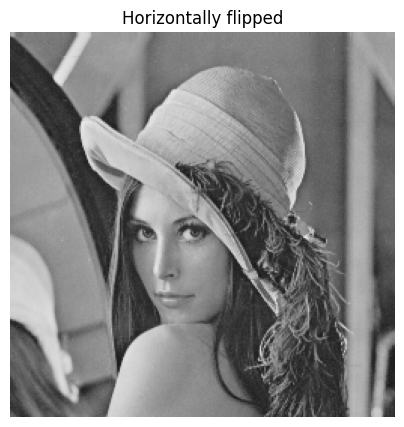

In [14]:
flipped = img_array[:, ::-1]

plt.figure(figsize=(5, 5))
plt.imshow(flipped, cmap="gray", vmin=0, vmax=255)
plt.title("Horizontally flipped")
plt.axis("off")
plt.show()


### F. Create a black-and-white image using a threshold


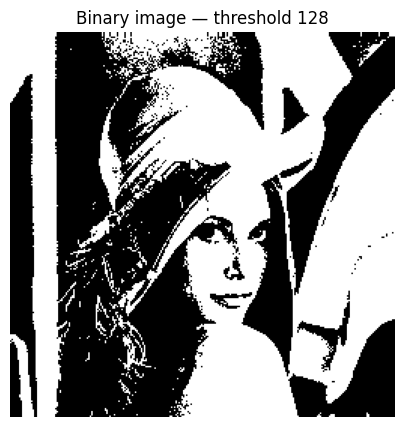

In [15]:
threshold_value = 128
binary = np.where(img_array > threshold_value, 255, 0).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(binary, cmap="gray", vmin=0, vmax=255)
plt.title(f"Binary image — threshold {threshold_value}")
plt.axis("off")
plt.show()


## Compare all results

The following figure shows how each NumPy operation changes the original image.


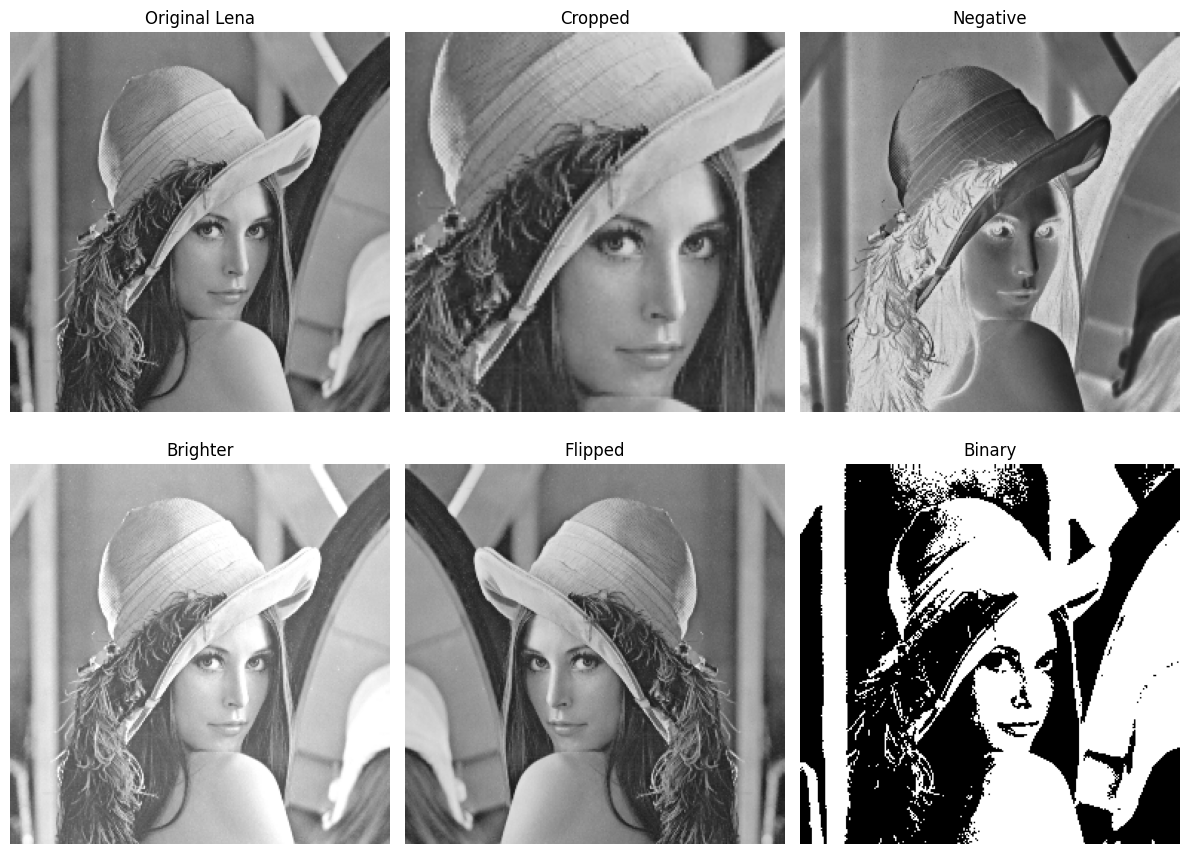

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 9))

comparisons = [
    (img_array, "Original Lena"),
    (cropped, "Cropped"),
    (negative, "Negative"),
    (brighter, "Brighter"),
    (flipped, "Flipped"),
    (binary, "Binary"),
]

for axis, (image, title) in zip(axes.flat, comparisons):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()


## Save all processed results


In [17]:
Image.fromarray(cropped).save(RESULTS_DIR / "lena_cropped.png")
Image.fromarray(negative).save(RESULTS_DIR / "lena_negative.png")
Image.fromarray(brighter).save(RESULTS_DIR / "lena_brighter.png")
Image.fromarray(flipped).save(RESULTS_DIR / "lena_flipped.png")
Image.fromarray(binary).save(RESULTS_DIR / "lena_binary.png")
fig.savefig(RESULTS_DIR / "numpy_operations_comparison.png", dpi=150, bbox_inches="tight")

print("All processed images saved in:", RESULTS_DIR)


All processed images saved in: /content/lab1_results


## Conclusion

- OpenCV loaded the camera image from disk.
- PIL loaded the grayscale Lena TIFF.
- Matplotlib displayed both images.
- NumPy represented Lena as a two-dimensional array and performed cropping, negative conversion, brightness adjustment, flipping, and thresholding.

### Check your understanding

1. Why does a grayscale image have two dimensions?
2. What do pixel values 0 and 255 represent?
3. Why is `np.clip()` used when increasing brightness?
4. What changes when the threshold changes from 128 to 80 or 180?

## Sources and redistribution note

- Camera: `skimage.data.camera()`. Scikit-image documents this replacement image as CC0 with no copyright restrictions, contributed by photographer Lav Varshney.
- Camera documentation: https://scikit-image.org/docs/stable/api/skimage.data
- Course gallery: https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html
- Lena: the `lena_gray_256.tif` file supplied for the course. Its public redistribution permission is not confirmed here. Keep the GitHub repository private or obtain the instructor/rightsholder's permission before publishing this embedded version publicly.
